# Подбор uplift-модели для рекламных предложений Criteo

**Постановка задачи:** подобрать оптимальный алгоритм для оценки аплифт-эффекта от рекламных предложений.

В этом ноутбуке собраны подходы:

- `Qini-curve.ipynb` — оценка качества через Qini-curve;
- `S-T-learners.ipynb` — S-learner и T-learner;
- `X-R-learners.ipynb` — X-learner и R-learner;
- `UpliftTree.ipynb` — UpliftRandomForest.

## 1. Импорт библиотек

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression

from causalml.inference.meta import (
    BaseSClassifier,
    BaseTClassifier,
    BaseXClassifier,
    BaseRClassifier,
)
from causalml.inference.tree import UpliftRandomForestClassifier

# CatBoost оставлен как опциональный более сильный базовый learner.
# По умолчанию ниже используется LogisticRegression, чтобы ноутбук выполнялся быстрее.
from catboost import CatBoostClassifier, CatBoostRegressor

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (7, 4)

RANDOM_STATE = 42

## 2. Загрузка данных

Файл Criteo большой, поэтому по умолчанию берём случайный семпл по всему `.csv.gz`, а не первые строки.

Это важно: в этом датасете первые строки могут относиться только к treatment-группе, поэтому `pd.read_csv(..., nrows=...)` даёт перекос.

In [5]:
feature_cols = [f'f{i}' for i in range(12)]
treatment_col = 'treatment'
target_col = 'conversion'

usecols = feature_cols + [treatment_col, target_col, 'visit', 'exposure']

# Настройки семплирования.
# SAMPLE_FRAC отвечает за долю строк, которую берём из каждого чанка.
# MAX_ROWS ограничивает итоговый размер, чтобы обучение не было слишком долгим.
SAMPLE_FRAC = 0.05
MAX_ROWS = 400_000
CHUNKSIZE = 1_000_000


def reduce_memory(df):
    df = df.copy()
    for col in feature_cols:
        df[col] = df[col].astype('float32')
    for col in [treatment_col, target_col, 'visit', 'exposure']:
        df[col] = df[col].astype('int8')
    return df


def load_criteo_sample(path, sample_frac=0.05, max_rows=400_000, chunksize=1_000_000, random_state=42):
    rng = np.random.default_rng(random_state)
    parts = []
    total_rows = 0
    sampled_rows = 0

    for chunk_number, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        total_rows += len(chunk)
        chunk = reduce_memory(chunk)

        if sample_frac is not None and sample_frac < 1:
            chunk = chunk.sample(
                frac=sample_frac,
                random_state=int(rng.integers(0, 1_000_000_000)),
            )

        parts.append(chunk)
        sampled_rows += len(chunk)
        print(f'chunk={chunk_number:02d}, total_rows={total_rows:,}, sampled_rows={sampled_rows:,}')

    df = pd.concat(parts, ignore_index=True)

    if max_rows is not None and len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=random_state).reset_index(drop=True)

    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df


df = load_criteo_sample(
    Path('data/criteo-uplift-v2.1.csv.gz'),
    sample_frac=SAMPLE_FRAC,
    max_rows=MAX_ROWS,
    chunksize=CHUNKSIZE,
    random_state=RANDOM_STATE,
)

print(f'Итоговый размер датасета: {df.shape}')
df.head()

chunk=01, total_rows=1,000,000, sampled_rows=50,000
chunk=02, total_rows=2,000,000, sampled_rows=100,000
chunk=03, total_rows=3,000,000, sampled_rows=150,000
chunk=04, total_rows=4,000,000, sampled_rows=200,000
chunk=05, total_rows=5,000,000, sampled_rows=250,000
chunk=06, total_rows=6,000,000, sampled_rows=300,000
chunk=07, total_rows=7,000,000, sampled_rows=350,000
chunk=08, total_rows=8,000,000, sampled_rows=400,000
chunk=09, total_rows=9,000,000, sampled_rows=450,000
chunk=10, total_rows=10,000,000, sampled_rows=500,000
chunk=11, total_rows=11,000,000, sampled_rows=550,000
chunk=12, total_rows=12,000,000, sampled_rows=600,000
chunk=13, total_rows=13,000,000, sampled_rows=650,000
chunk=14, total_rows=13,979,592, sampled_rows=698,980
Итоговый размер датасета: (400000, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,23.845728,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
1,26.388430,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616364,10.059654,8.663068,4.679882,10.280525,4.115453,0.294443,4.833815,3.943716,18.380112,5.300375,-0.168679,0,0,0,0
3,22.840899,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
4,23.835009,10.059654,8.214383,4.679882,10.280525,4.115453,-3.993764,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0


## 3. Первичная проверка датасета

В качестве признаков используем только `f0`–`f11`.

`conversion` — целевая переменная, факт конверсии.

`treatment` — факт попадания пользователя в группу воздействия.

`visit` и `exposure` не используем как признаки, потому что это уже поведенческие/post-treatment переменные. Если добавить их в признаки, можно получить утечку информации и завышенную оценку качества.

In [6]:
print('Размер:', df.shape)
print('Пропуски:')
display(df.isna().sum())

print('Распределение treatment:')
display(df[treatment_col].value_counts(normalize=True).rename('share'))

print('Распределение conversion:')
display(df[target_col].value_counts(normalize=True).rename('share'))

print('Конверсия по группам:')
conversion_by_treatment = df.groupby(treatment_col)[target_col].agg(['count', 'mean'])
display(conversion_by_treatment)

print('Таблица treatment x conversion:')
display(pd.crosstab(df[treatment_col], df[target_col]))

Размер: (400000, 16)
Пропуски:


f0            0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
treatment     0
conversion    0
visit         0
exposure      0
dtype: int64

Распределение treatment:


treatment
1    0.850283
0    0.149718
Name: share, dtype: float64

Распределение conversion:


conversion
0    0.997145
1    0.002855
Name: share, dtype: float64

Конверсия по группам:


,count,mean
treatment,,
0,59887,0.00192
1,340113,0.00302


Таблица treatment x conversion:


conversion,0,1
treatment,,
0,59772,115
1,339086,1027


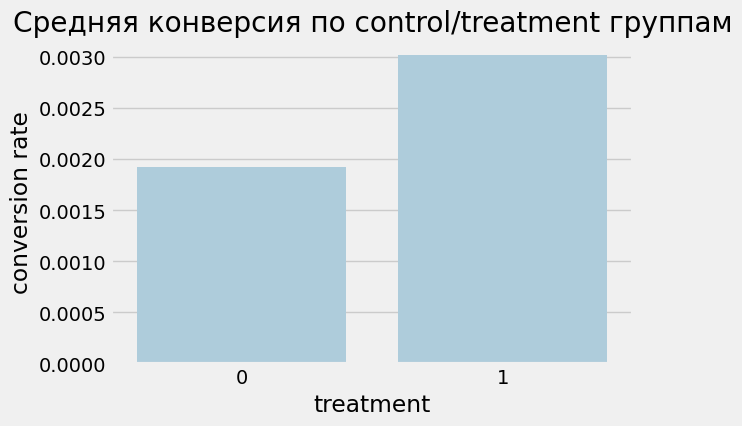

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=df.groupby(treatment_col, as_index=False)[target_col].mean(),
    x=treatment_col,
    y=target_col,
    ax=ax,
)
ax.set_title('Средняя конверсия по control/treatment группам')
ax.set_xlabel('treatment')
ax.set_ylabel('conversion rate')
plt.show()

## 4. Train/validation split

Для честного сравнения моделей нужен один и тот же валидационный датасет.

Стратификацию делаем по комбинации `treatment + conversion`, чтобы сохранить доли:

- control без конверсии;
- control с конверсией;
- treatment без конверсии;
- treatment с конверсией.

In [8]:
df['stratify_col'] = (
    df[treatment_col].astype(str)
    + '_'
    + df[target_col].astype(str)
)

train_df, valid_df = train_test_split(
    df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df['stratify_col'],
)

train_df = train_df.drop(columns='stratify_col').reset_index(drop=True)
valid_df = valid_df.drop(columns='stratify_col').reset_index(drop=True)

df = df.drop(columns='stratify_col')

print(f'train shape: {train_df.shape}')
print(f'valid shape: {valid_df.shape}')

print('Train treatment x conversion:')
display(pd.crosstab(train_df[treatment_col], train_df[target_col]))

print('Valid treatment x conversion:')
display(pd.crosstab(valid_df[treatment_col], valid_df[target_col]))

train shape: (300000, 16)
valid shape: (100000, 16)
Train treatment x conversion:


conversion,0,1
treatment,,
0,44829,86
1,254315,770


Valid treatment x conversion:


conversion,0,1
treatment,,
0,14943,29
1,84771,257


## 5. Масштабирование признаков

Логистическая регрессия чувствительна к масштабу признаков, поэтому признаки `f0`–`f11` стандартизируем.

Для всех моделей используем одинаковые `X_train` и `X_valid`, чтобы сравнение было честным.

In [9]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(train_df[feature_cols]),
    columns=feature_cols,
)

X_valid = pd.DataFrame(
    scaler.transform(valid_df[feature_cols]),
    columns=feature_cols,
)

t_train = train_df[treatment_col].values
t_valid = valid_df[treatment_col].values

y_train = train_df[target_col].values
y_valid = valid_df[target_col].values

print(X_train.shape, X_valid.shape)

(300000, 12) (100000, 12)


## 6. Функция Qini-curve и вспомогательные функции

1. сортируем пользователей по предсказанному `uplift_score` от большего к меньшему;
2. считаем накопленную конверсию в treatment и control;
3. строим модельную Qini-кривую;
4. строим случайную Qini-кривую;
5. считаем площадь/разницу между ними.

Для сравнения моделей используем `valid_qini_sum`: чем больше, тем лучше модель ранжирует пользователей по ожидаемому рекламному эффекту.

In [10]:
def flatten_uplift(pred):
    pred = np.asarray(pred)

    if pred.ndim == 1:
        return pred.ravel()

    if pred.ndim == 2 and pred.shape[1] == 1:
        return pred[:, 0]

    # На случай, если модель вернула несколько столбцов для нескольких treatment-групп.
    # В нашей задаче treatment бинарный, поэтому берём последний столбец как эффект воздействия.
    if pred.ndim == 2:
        return pred[:, -1]

    return pred.reshape(-1)


def qini_df(df_eval, title='valid', figsize=(6, 4), plot=True):
    ranked = df_eval.sort_values('uplift_score', ascending=False).copy()

    n_t = (ranked[treatment_col] == 1).sum()
    n_c = (ranked[treatment_col] == 0).sum()

    if n_t == 0 or n_c == 0:
        raise ValueError('В выборке должны быть и treatment, и control наблюдения.')

    ranked['n_t1'] = ((ranked[treatment_col] == 1) & (ranked[target_col] == 1)).astype(int)
    ranked['n_c1'] = ((ranked[treatment_col] == 0) & (ranked[target_col] == 1)).astype(int)

    ranked['n_t1/nt'] = ranked['n_t1'].cumsum() / n_t
    ranked['n_c1/nc'] = ranked['n_c1'].cumsum() / n_c

    ranked['uplift'] = ranked['n_t1/nt'] - ranked['n_c1/nc']
    ranked['n'] = np.arange(1, len(ranked) + 1) / len(ranked)
    ranked['random_uplift'] = ranked['n'] * ranked['uplift'].iloc[-1]

    qini_sum = (ranked['uplift'] - ranked['random_uplift']).sum()
    qini_area = np.trapz(ranked['uplift'] - ranked['random_uplift'], ranked['n'])

    if plot:
        plt.figure(figsize=figsize)
        plt.plot(ranked['n'], ranked['uplift'], label='Model')
        plt.plot(ranked['n'], ranked['random_uplift'], label='Random model')
        plt.axhline(0, linestyle='--', linewidth=1)
        plt.legend()
        plt.title(f'Qini-curve: {title}')
        plt.xlabel('Доля пользователей')
        plt.ylabel('Накопленный uplift')
        plt.show()

    print(f'Qini score sum: {qini_sum:.3f}')
    print(f'Qini area: {qini_area:.6f}')

    return {
        'qini_sum': qini_sum,
        'qini_area': qini_area,
    }


results = []


def evaluate_model(model_name, train_uplift, valid_uplift, plot=True):
    train_eval = train_df[[treatment_col, target_col]].copy()
    valid_eval = valid_df[[treatment_col, target_col]].copy()

    train_eval['uplift_score'] = flatten_uplift(train_uplift)
    valid_eval['uplift_score'] = flatten_uplift(valid_uplift)

    print(f'===== {model_name}: train =====')
    train_score = qini_df(train_eval, title=f'{model_name}: train', plot=plot)

    print(f'===== {model_name}: valid =====')
    valid_score = qini_df(valid_eval, title=f'{model_name}: valid', plot=plot)

    results.append({
        'model': model_name,
        'train_qini_sum': train_score['qini_sum'],
        'valid_qini_sum': valid_score['qini_sum'],
        'train_qini_area': train_score['qini_area'],
        'valid_qini_area': valid_score['qini_area'],
    })

    return train_score, valid_score

## 7. Базовые learner-модели

По умолчанию используем `LogisticRegression` и `LinearRegression`, потому что они быстро обучаются даже на большом датасете.

Если хочется более сильный, но более долгий вариант, можно поставить:

```python
USE_CATBOOST = True
```

In [11]:
USE_CATBOOST = False


def make_outcome_classifier():
    if USE_CATBOOST:
        return CatBoostClassifier(
            iterations=100,
            depth=5,
            learning_rate=0.05,
            random_seed=RANDOM_STATE,
            verbose=0,
            allow_writing_files=False,
        )

    return LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    )


def make_effect_regressor():
    if USE_CATBOOST:
        return CatBoostRegressor(
            iterations=100,
            depth=5,
            learning_rate=0.05,
            random_seed=RANDOM_STATE,
            verbose=0,
            allow_writing_files=False,
        )

    return LinearRegression()

## 8. S-learner

S-learner обучает одну модель, куда `treatment` передаётся как дополнительный признак.

После обучения uplift считается как разность двух прогнозов:

- вероятность конверсии при `treatment = 1`;
- вероятность конверсии при `treatment = 0`.

===== S-learner: train =====


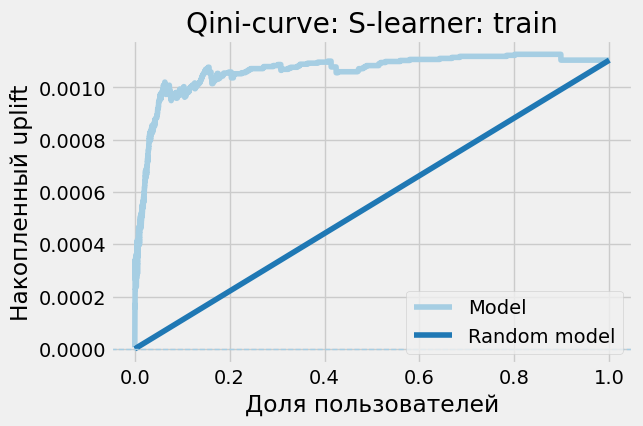

Qini score sum: 153.128
Qini area: 0.000510
===== S-learner: valid =====


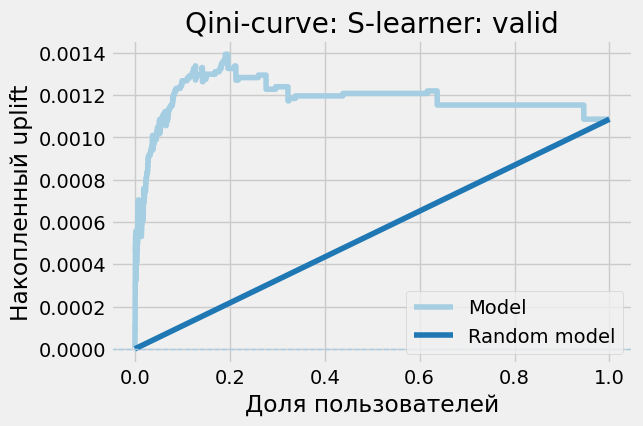

Qini score sum: 63.317
Qini area: 0.000633


({'qini_sum': 153.1281211392602, 'qini_area': 0.0005104270639365637},
 {'qini_sum': 63.316878062301576, 'qini_area': 0.000633168780677295})

In [12]:
s_learner = BaseSClassifier(
    learner=make_outcome_classifier(),
)

s_learner.fit(
    X=X_train,
    treatment=t_train,
    y=y_train,
)

s_train_uplift = s_learner.predict(np.array(X_train.values.copy()))
s_valid_uplift = s_learner.predict(np.array(X_valid.values.copy()))

evaluate_model('S-learner', s_train_uplift, s_valid_uplift)

## 9. T-learner

T-learner обучает две отдельные модели:

- одну на treatment-группе;
- вторую на control-группе.

Uplift считается как разность прогнозов этих двух моделей.

===== T-learner: train =====


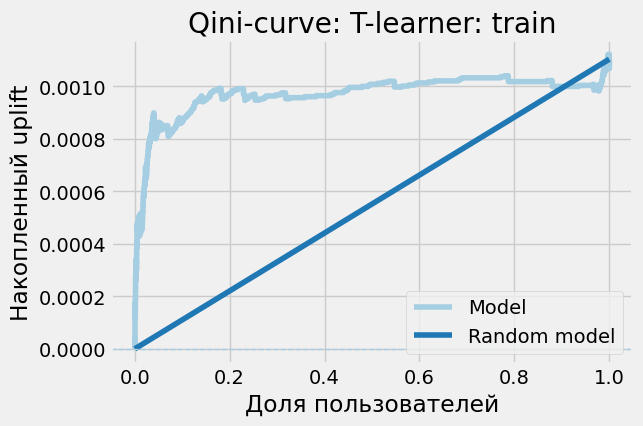

Qini score sum: 125.244
Qini area: 0.000417
===== T-learner: valid =====


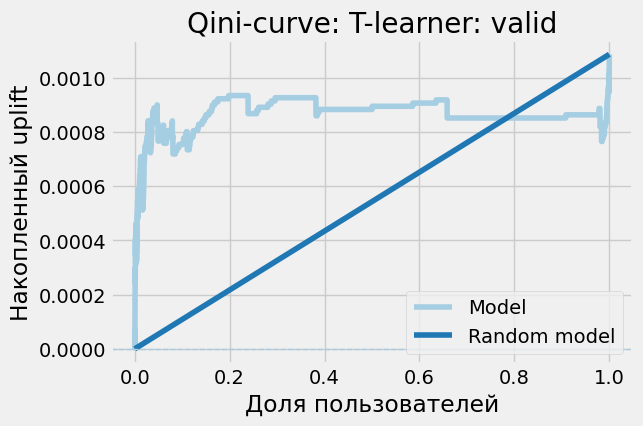

Qini score sum: 32.021
Qini area: 0.000320


({'qini_sum': 125.24382429239648, 'qini_area': 0.000417479414314121},
 {'qini_sum': 32.020615016152014, 'qini_area': 0.0003202061502157994})

In [13]:
t_learner = BaseTClassifier(
    learner=make_outcome_classifier(),
)

t_learner.fit(
    X=X_train,
    treatment=t_train,
    y=y_train,
)

t_train_uplift = t_learner.predict(np.array(X_train.values.copy()))
t_valid_uplift = t_learner.predict(np.array(X_valid.values.copy()))

evaluate_model('T-learner', t_train_uplift, t_valid_uplift)

## 10. X-learner

X-learner хорошо подходит для ситуаций, где группы treatment/control несбалансированы.

В Criteo treatment-группа обычно намного больше control-группы, поэтому X-learner здесь особенно уместен.

===== X-learner: train =====


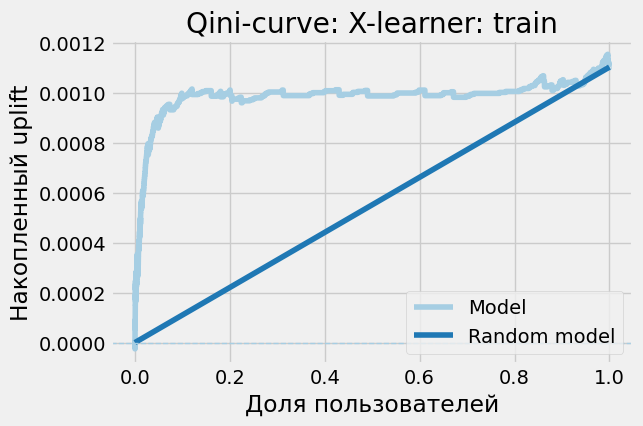

Qini score sum: 130.203
Qini area: 0.000434
===== X-learner: valid =====


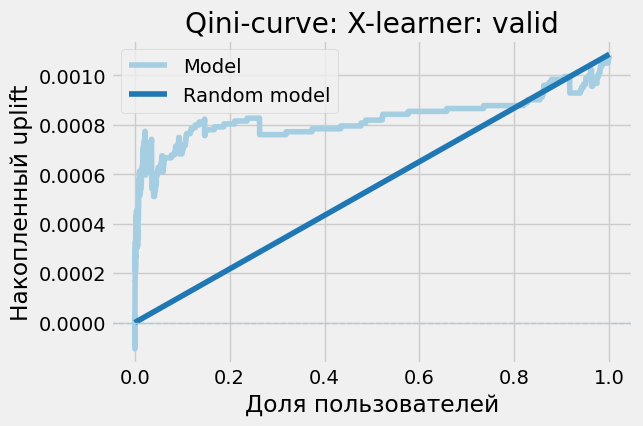

Qini score sum: 28.309
Qini area: 0.000283


({'qini_sum': 130.2033094996497, 'qini_area': 0.00043401103167163167},
 {'qini_sum': 28.309309949804405, 'qini_area': 0.0002830930407481646})

In [14]:
x_learner = BaseXClassifier(
    outcome_learner=make_outcome_classifier(),
    effect_learner=make_effect_regressor(),
)

x_learner.fit(
    X=X_train,
    treatment=t_train,
    y=y_train,
)

x_train_uplift = x_learner.predict(np.array(X_train.values.copy()))
x_valid_uplift = x_learner.predict(np.array(X_valid.values.copy()))

evaluate_model('X-learner', x_train_uplift, x_valid_uplift)

## 11. R-learner

R-learner отдельно учитывает модель отклика и модель вероятности treatment.

В задачах с сильным дисбалансом и большим количеством наблюдений он часто оказывается хорошим кандидатом, но итоговый выбор всё равно делаем по validation Qini.

===== R-learner: train =====


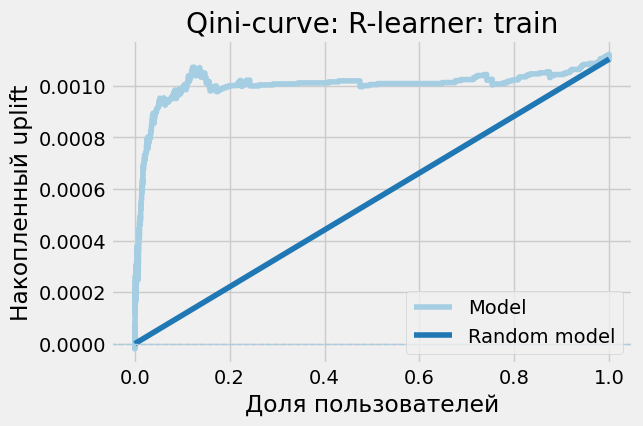

Qini score sum: 135.032
Qini area: 0.000450
===== R-learner: valid =====


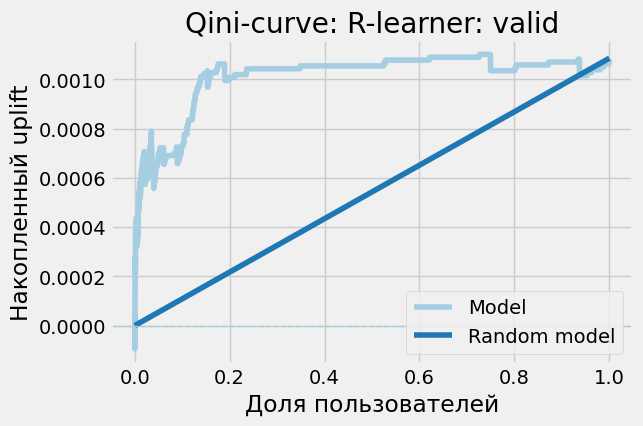

Qini score sum: 46.481
Qini area: 0.000465


({'qini_sum': 135.03156990072515, 'qini_area': 0.00045010523300854986},
 {'qini_sum': 46.481205496500586, 'qini_area': 0.0004648119962151265})

In [15]:
r_learner = BaseRClassifier(
    outcome_learner=make_outcome_classifier(),
    effect_learner=make_effect_regressor(),
    random_state=RANDOM_STATE,
)

r_learner.fit(
    X=X_train,
    treatment=t_train,
    y=y_train,
)

r_train_uplift = r_learner.predict(np.array(X_train.values.copy()))
r_valid_uplift = r_learner.predict(np.array(X_valid.values.copy()))

evaluate_model('R-learner', r_train_uplift, r_valid_uplift)

## 12. UpliftRandomForest

UpliftRandomForest строит деревья, которые оптимизируют не обычную точность классификации, а различие отклика между treatment и control.

Для деревьев из `CausalML` `treatment` нужно передавать строкой, поэтому используем `.astype(str)` и `control_name='0'`.

===== UpliftRandomForest: train =====


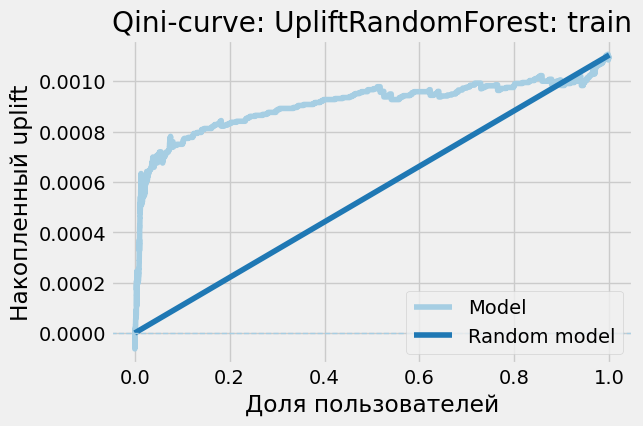

Qini score sum: 105.739
Qini area: 0.000352
===== UpliftRandomForest: valid =====


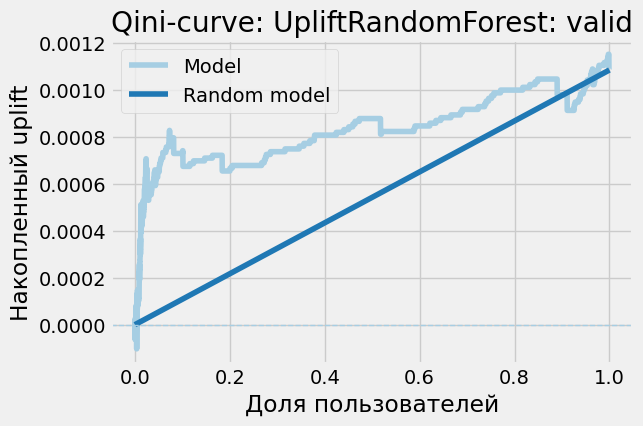

Qini score sum: 28.874
Qini area: 0.000289


({'qini_sum': 105.73892819233022, 'qini_area': 0.00035246309398056667},
 {'qini_sum': 28.874265287362523, 'qini_area': 0.0002887426529279045})

In [16]:
uplift_forest = UpliftRandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_leaf=200,
    min_samples_treatment=50,
    n_reg=100,
    evaluationFunction='ED',
    control_name='0',
    random_state=RANDOM_STATE,
)

uplift_forest.fit(
    X_train.values,
    treatment=pd.Series(t_train).astype(str).values,
    y=y_train,
)

forest_train_uplift = uplift_forest.predict(np.array(X_train.values.copy()))
forest_valid_uplift = uplift_forest.predict(np.array(X_valid.values.copy()))

evaluate_model('UpliftRandomForest', forest_train_uplift, forest_valid_uplift)

## 13. Сравнение моделей

Сравнивать модели нужно по валидации, а не по train.

Если у модели высокий `train_qini_sum`, но низкий `valid_qini_sum`, значит модель переобучилась и плохо переносится на новых пользователей.

,model,train_qini_sum,valid_qini_sum,train_qini_area,valid_qini_area,overfit_gap
0,S-learner,153.128121,63.316878,0.000510,0.000633,89.811243
1,R-learner,135.031570,46.481205,0.000450,0.000465,88.550364
2,T-learner,125.243824,32.020615,0.000417,0.000320,93.223209
3,UpliftRandomForest,105.738928,28.874265,0.000352,0.000289,76.864663
4,X-learner,130.203309,28.309310,0.000434,0.000283,101.894000


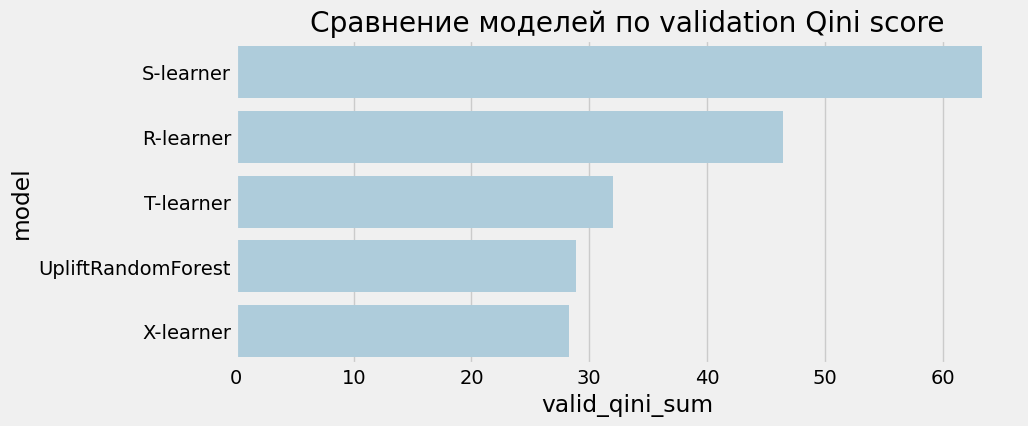

In [17]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('valid_qini_sum', ascending=False).reset_index(drop=True)

results_df['overfit_gap'] = results_df['train_qini_sum'] - results_df['valid_qini_sum']

display(results_df)

plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x='valid_qini_sum', y='model')
plt.title('Сравнение моделей по validation Qini score')
plt.xlabel('valid_qini_sum')
plt.ylabel('model')
plt.show()

## 14. Итоговый вывод для бизнес-кейса

In [18]:
best_row = results_df.iloc[0]

print(f'Лучшая модель по validation Qini: {best_row["model"]}')
print(f'Validation Qini score sum: {best_row["valid_qini_sum"]:.3f}')
print(f'Validation Qini area: {best_row["valid_qini_area"]:.6f}')
print(f'Разрыв train-valid: {best_row["overfit_gap"]:.3f}')

print('Бизнес-вывод:')
print(
    'Для показа рекламных предложений нужно использовать модель с максимальным validation Qini, '
    'потому что она лучше ранжирует пользователей по ожидаемому дополнительному эффекту от рекламы. '
    'Именно такую модель логично применять для таргетинга: сначала показывать рекламу пользователям '
    'с самым высоким predicted uplift, а не всем подряд.'
)

if best_row['overfit_gap'] > abs(best_row['valid_qini_sum']):
    print('Важно: у лучшей модели заметный разрыв между train и validation. '
          'Перед промышленным использованием стоит уменьшить сложность модели, увеличить выборку или подобрать гиперпараметры.'
    )
else:
    print('Модель выглядит приемлемо: качество на validation не провалилось относительно train. '
        'Её можно взять как основной кандидат для дальнейшего A/B-теста.'
    )

Лучшая модель по validation Qini: S-learner
Validation Qini score sum: 63.317
Validation Qini area: 0.000633
Разрыв train-valid: 89.811
Бизнес-вывод:
Для показа рекламных предложений нужно использовать модель с максимальным validation Qini, потому что она лучше ранжирует пользователей по ожидаемому дополнительному эффекту от рекламы. Именно такую модель логично применять для таргетинга: сначала показывать рекламу пользователям с самым высоким predicted uplift, а не всем подряд.
Важно: у лучшей модели заметный разрыв между train и validation. Перед промышленным использованием стоит уменьшить сложность модели, увеличить выборку или подобрать гиперпараметры.


## Вывод

По результатам сравнения uplift-моделей лучшей моделью оказался S-learner. 
Он получил максимальное значение Qini-score на валидационной выборке: 63.317. 
Это означает, что S-learner лучше остальных моделей ранжирует пользователей по ожидаемому дополнительному эффекту от показа рекламы.

Вероятная причина такого результата — сильная несбалансированность данных и очень редкая конверсия. 
В датасете treatment-группа значительно больше control-группы, а доля конверсий составляет меньше 1%. 
Из-за этого моделям, которые обучают несколько отдельных компонент, например T-learner, X-learner и R-learner, сложнее стабильно оценить эффект воздействия. 
S-learner обучает одну общую модель на всех данных сразу, поэтому он использует больше информации и даёт более устойчивое ранжирование пользователей.

Для бизнес-кейса рекламного агентства Criteo целесообразно выбрать S-learner как основной базовый вариант модели. 
Эту модель можно использовать для таргетинга рекламных предложений: рекламу следует в первую очередь показывать пользователям с максимальным predicted uplift. 
Такой подход лучше, чем показ рекламы всем подряд, потому что позволяет направлять рекламный бюджет на пользователей, у которых реклама с наибольшей вероятностью действительно увеличит шанс конверсии.

При этом у S-learner заметен разрыв между train и validation Qini-score, поэтому перед промышленным использованием модель стоит дополнительно проверить на более крупной выборке, подобрать гиперпараметры и провести A/B-тест.